### Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

### Step 2 — Load Final Cleaned Dataset

In [2]:
df = pd.read_csv("../Dataset/f1_final_cleaned_data.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (7109, 28)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,podium,driver_name,constructor_name,round,race_name,circuitId,date,circuit_name,location,country,qualifying_position
0,20323,337,4,6,8,3.0,1.0,1,1,25.0,49,45.0,1.0,1:58.287,191.706,1,2010,1,Fernando Alonso,Ferrari,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,3.0
1,20324,337,13,6,7,2.0,2.0,2,2,18.0,49,38.0,5.0,1:59.732,189.392,1,2010,1,Felipe Massa,Ferrari,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,2.0
2,20325,337,1,1,2,4.0,3.0,3,3,15.0,49,42.0,4.0,1:59.560,189.665,1,2010,1,Lewis Hamilton,McLaren,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,4.0
3,20326,337,20,9,5,1.0,4.0,4,4,12.0,49,32.0,12.0,2:00.218,188.627,1,2010,0,Sebastian Vettel,Red Bull,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,1.0
4,20327,337,3,131,4,5.0,5.0,5,5,10.0,49,45.0,13.0,2:00.236,188.599,1,2010,0,Nico Rosberg,Mercedes,1,Bahrain Grand Prix,3,2010-03-14,Bahrain International Circuit,Sakhir,Bahrain,5.0


### Step 3 — Check Dataset Summary Statistics

In [3]:
df.describe()

,resultId,raceId,driverId,constructorId,number,grid,position,positionOrder,points,laps,fastestLap,rank,fastestLapSpeed,statusId,year,podium,round,circuitId,qualifying_position
count,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000,7109.000000
mean,23897.400338,964.427908,560.935012,74.176115,23.598115,10.831763,11.071037,11.071037,4.830567,53.393586,45.405964,10.313828,203.634672,9.233366,2017.796737,0.143058,10.633563,24.652272,11.042481
std,2064.227704,188.725774,381.242286,86.999586,22.294446,6.195883,6.173959,6.173959,7.138913,17.825164,14.882556,6.177988,19.929812,20.173662,4.882515,0.350157,6.013004,24.773494,6.150810
min,20323.000000,337.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,89.540000,1.000000,2010.000000,0.000000,1.000000,1.000000,1.000000
25%,22108.000000,898.000000,20.000000,5.000000,8.000000,6.000000,6.000000,6.000000,0.000000,51.000000,39.000000,5.000000,193.663000,1.000000,2013.000000,0.000000,5.000000,7.000000,6.000000
50%,23900.000000,994.000000,818.000000,10.000000,18.000000,11.000000,11.000000,11.000000,0.000000,56.000000,48.000000,10.000000,203.959500,1.000000,2018.000000,0.000000,10.000000,14.000000,11.000000
75%,25684.000000,1087.000000,840.000000,164.000000,27.000000,16.000000,16.000000,16.000000,8.000000,66.000000,54.000000,15.000000,214.631000,11.000000,2022.000000,0.000000,16.000000,32.000000,16.000000
max,27485.000000,1179.000000,866.000000,217.000000,99.000000,24.000000,24.000000,24.000000,50.000000,87.000000,85.000000,24.000000,256.100000,143.000000,2026.000000,1.000000,24.000000,80.000000,24.000000


### Step 4 — Check Podium Distribution

In [4]:
podium_counts = df["podium"].value_counts().sort_index()

print(podium_counts)

podium
0    6092
1    1017
Name: count, dtype: int64


### Step 5 — Plot Podium Distribution

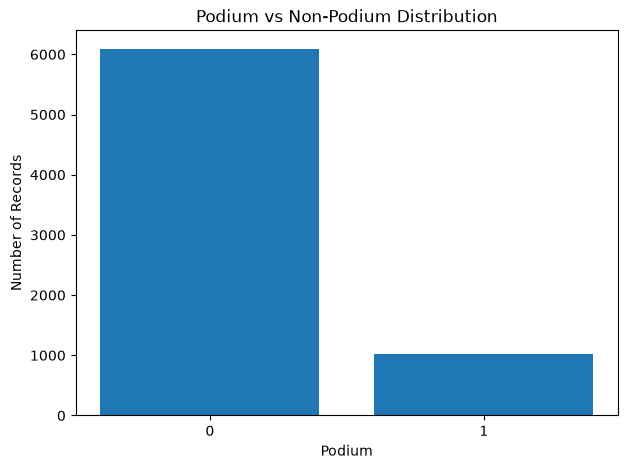

In [5]:
plt.figure(figsize=(7, 5))

plt.bar(
    podium_counts.index.astype(str),
    podium_counts.values
)

plt.xlabel("Podium")
plt.ylabel("Number of Records")
plt.title("Podium vs Non-Podium Distribution")

plt.show()

### Step 6 — Analyze Podium Percentage by Grid Position

In [6]:
grid_podium = df.groupby("grid")["podium"].mean() * 100

grid_podium.head(20)

grid
0.0      0.000000
1.0     80.235988
2.0     69.732938
3.0     50.737463
4.0     36.578171
5.0     19.469027
6.0     12.979351
7.0      7.988166
8.0      2.662722
9.0      4.129794
10.0     3.857567
11.0     2.077151
12.0     1.474926
13.0     1.186944
14.0     1.183432
15.0     1.186944
16.0     0.296736
17.0     0.879765
18.0     0.602410
19.0     1.230769
Name: podium, dtype: float64

### Step 7 — Plot Podium Percentage by Grid Position

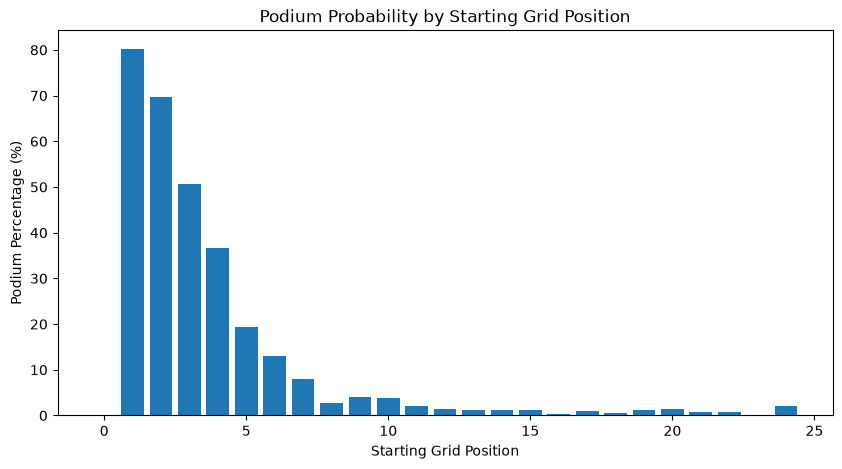

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    grid_podium.index,
    grid_podium.values
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Percentage (%)")
plt.title("Podium Probability by Starting Grid Position")

plt.show()

#### Step 8 — Analyze Podium Percentage by Qualifying Position

In [9]:
qualifying_podium = (
    df.groupby("qualifying_position")["podium"].mean() * 100
)

qualifying_podium.head(20)

qualifying_position
1.0     79.646018
2.0     67.256637
3.0     49.557522
4.0     38.643068
5.0     23.598820
6.0     12.684366
7.0      7.374631
8.0      2.654867
9.0      3.539823
10.0     3.539823
11.0     2.359882
12.0     1.764706
13.0     0.882353
14.0     0.887574
15.0     1.769912
16.0     0.589971
17.0     0.884956
18.0     0.294985
19.0     0.600601
20.0     0.928793
Name: podium, dtype: float64

### Step 9 — Plot Podium Percentage by Qualifying Position

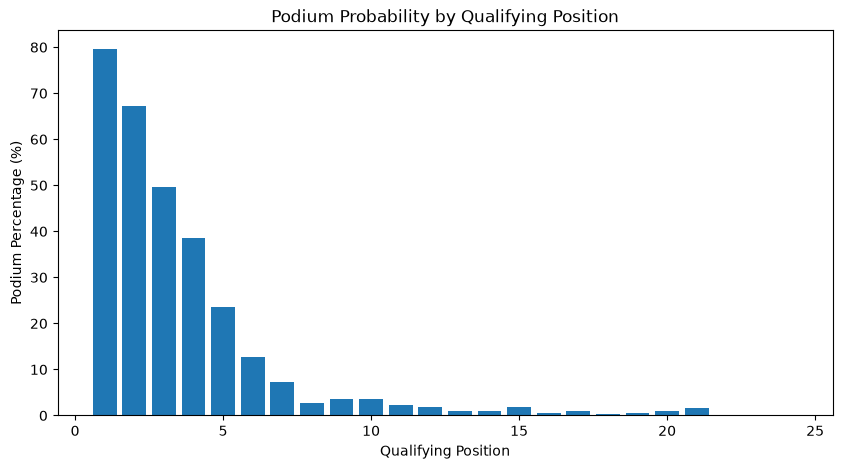

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    qualifying_podium.index,
    qualifying_podium.values
)

plt.xlabel("Qualifying Position")
plt.ylabel("Podium Percentage (%)")
plt.title("Podium Probability by Qualifying Position")

plt.show()

### Step 10 — Analyze Average Finishing Position by Starting Grid

In [12]:
grid_finish = (
    df.groupby("grid")["positionOrder"]
    .mean()
)

grid_finish.head(20)

grid
0.0     15.378049
1.0      3.504425
2.0      4.418398
3.0      5.528024
4.0      6.005900
5.0      7.699115
6.0      7.988201
7.0      9.044379
8.0     10.295858
9.0     10.554572
10.0    10.910979
11.0    11.543027
12.0    12.253687
13.0    12.833828
14.0    13.452663
15.0    13.507418
16.0    14.397626
17.0    14.583578
18.0    15.234940
19.0    15.360000
Name: positionOrder, dtype: float64

 ### Step 11 — Plot Average Finishing Position by Starting Grid

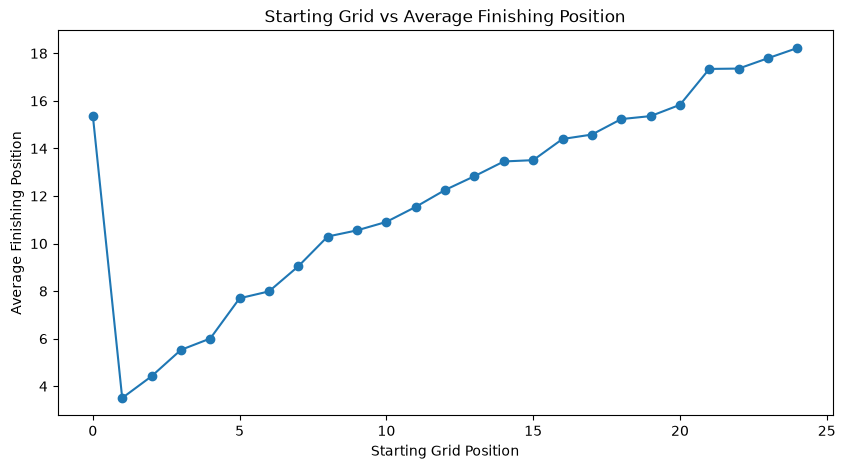

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    grid_finish.index,
    grid_finish.values,
    marker="o"
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Average Finishing Position")
plt.title("Starting Grid vs Average Finishing Position")

plt.show()

###  Step 12 — Analyze Top Drivers by Podium Count

In [14]:
driver_podiums = (
    df.groupby("driver_name")["podium"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

driver_podiums

driver_name
Lewis Hamilton      180
Max Verstappen      130
Sebastian Vettel    113
Valtteri Bottas      67
Nico Rosberg         55
Charles Leclerc      54
Fernando Alonso      53
Lando Norris         47
Kimi Räikkönen       41
Sergio Pérez         39
Daniel Ricciardo     32
Mark Webber          32
George Russell       29
Carlos Sainz         28
Oscar Piastri        27
Name: podium, dtype: int64

### Step 13 — Plot Top 15 Drivers by Podium Count

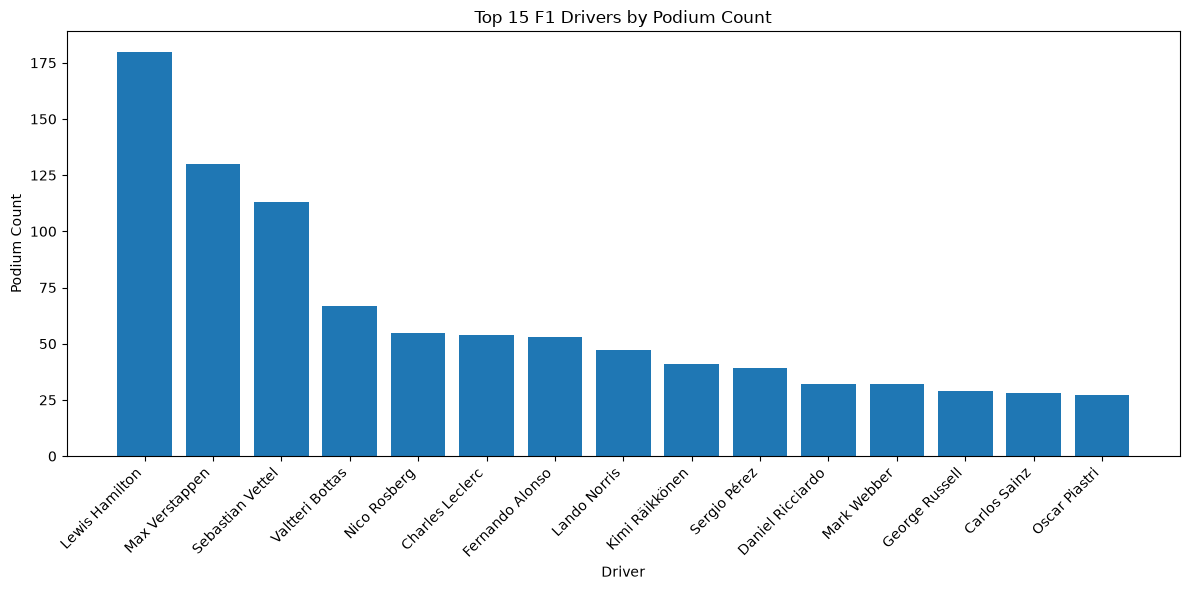

In [15]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_podiums.index,
    driver_podiums.values
)

plt.xlabel("Driver")
plt.ylabel("Podium Count")
plt.title("Top 15 F1 Drivers by Podium Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 14 — Analyze Top Constructors by Podium Count

In [16]:
constructor_podiums = (
    df.groupby("constructor_name")["podium"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

constructor_podiums

constructor_name
Mercedes          307
Red Bull          281
Ferrari           217
McLaren           126
Lotus F1           25
Williams           18
Aston Martin        9
Renault             8
Alpine F1 Team      7
Sauber              5
Force India         5
Racing Point        4
Toro Rosso          2
AlphaTauri          2
RB F1 Team          1
Name: podium, dtype: int64

### Step 15 — Plot Top 15 Constructors by Podium Count

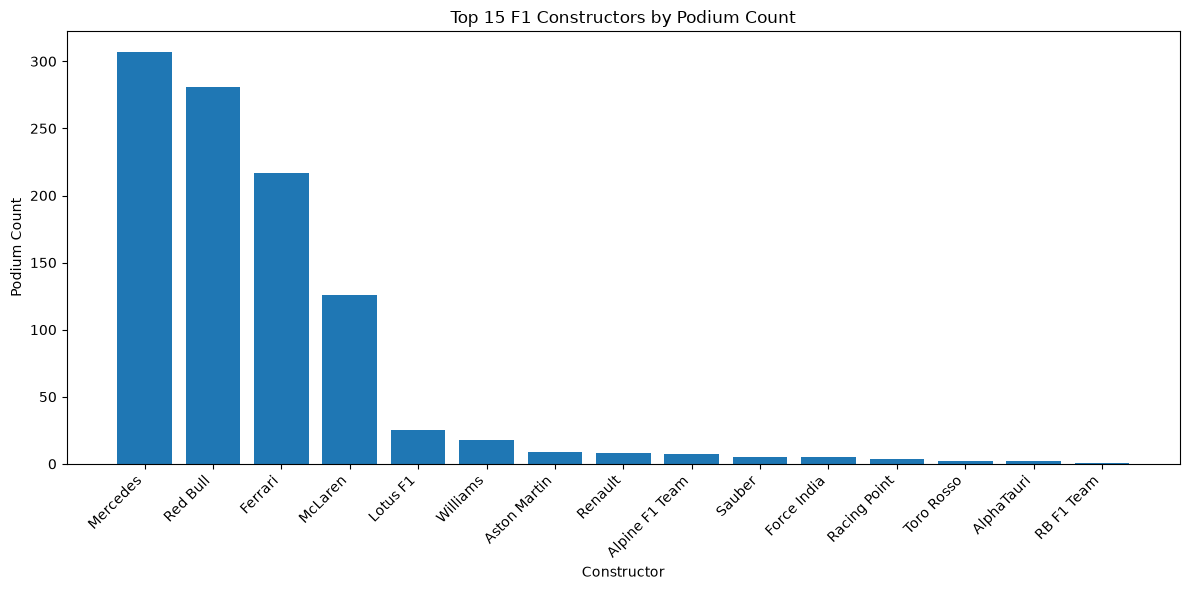

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    constructor_podiums.index,
    constructor_podiums.values
)

plt.xlabel("Constructor")
plt.ylabel("Podium Count")
plt.title("Top 15 F1 Constructors by Podium Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 16 — Analyze Podiums by Season

In [18]:
season_podiums = (
    df.groupby("year")["podium"]
    .sum()
)

season_podiums.tail(15)

year
2012    60
2013    57
2014    57
2015    57
2016    63
2017    60
2018    63
2019    63
2020    51
2021    66
2022    66
2023    66
2024    72
2025    69
2026    33
Name: podium, dtype: int64

### Step 17 — Plot Podiums by Season

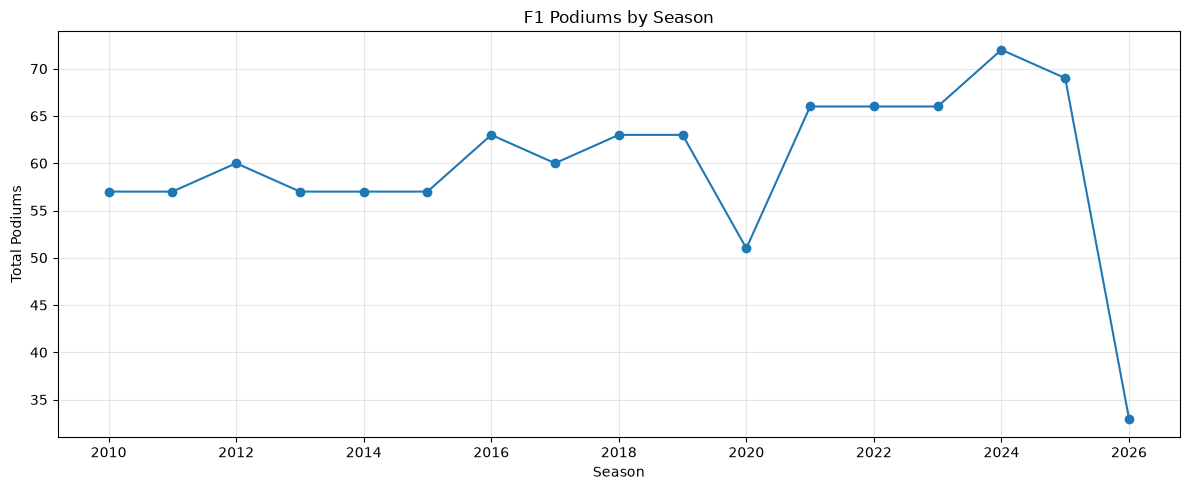

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    season_podiums.index,
    season_podiums.values,
    marker="o"
)

plt.xlabel("Season")
plt.ylabel("Total Podiums")
plt.title("F1 Podiums by Season")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Step 18 — Analyze Average Points by Driver

In [20]:
driver_points = (
    df.groupby("driver_name")["points"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

driver_points

driver_name
Lewis Hamilton           14.350592
Max Verstappen           13.919421
Sebastian Vettel         11.582031
Mark Webber              11.402597
Nico Rosberg             11.169118
Oscar Piastri             9.812500
Andrea Kimi Antonelli     9.500000
Charles Leclerc           9.295082
Lando Norris              8.851852
Valtteri Bottas           6.930233
Jenson Button             6.725926
George Russell            6.660494
Kimi Räikkönen            6.635897
Fernando Alonso           6.033670
Felipe Massa              5.464516
Name: points, dtype: float64

#### Step 19 — Plot Top 15 Drivers by Average Points

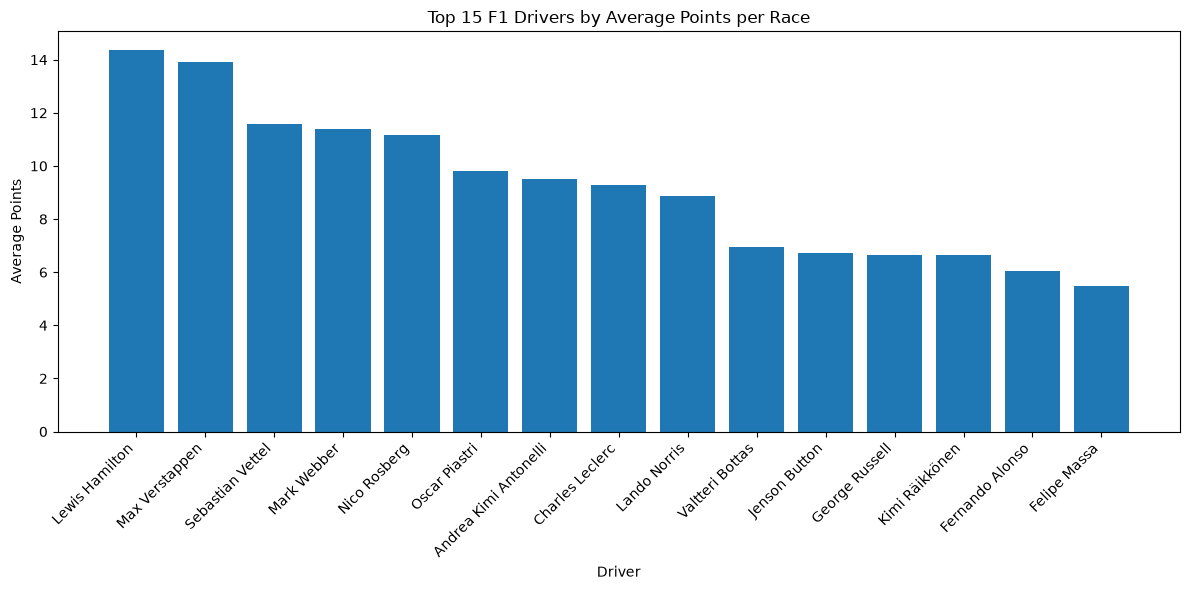

In [21]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_points.index,
    driver_points.values
)

plt.xlabel("Driver")
plt.ylabel("Average Points")
plt.title("Top 15 F1 Drivers by Average Points per Race")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 20 — Analyze Average Finishing Position by Driver

In [22]:
driver_finish = (
    df.groupby("driver_name")["positionOrder"]
    .mean()
    .sort_values()
    .head(15)
)

driver_finish

driver_name
Lewis Hamilton           5.011834
Max Verstappen           5.586777
Mark Webber              6.259740
Sebastian Vettel         6.535156
Nico Rosberg             6.683824
Oscar Piastri            7.100000
Lando Norris             7.370370
Charles Leclerc          7.371585
Andrea Kimi Antonelli    8.117647
Kimi Räikkönen           8.769231
Jenson Button            9.244444
Felipe Massa             9.251613
Valtteri Bottas          9.379845
George Russell           9.425926
Fernando Alonso          9.606061
Name: positionOrder, dtype: float64

### Step 21 — Plot Top 15 Drivers by Average Finishing Position

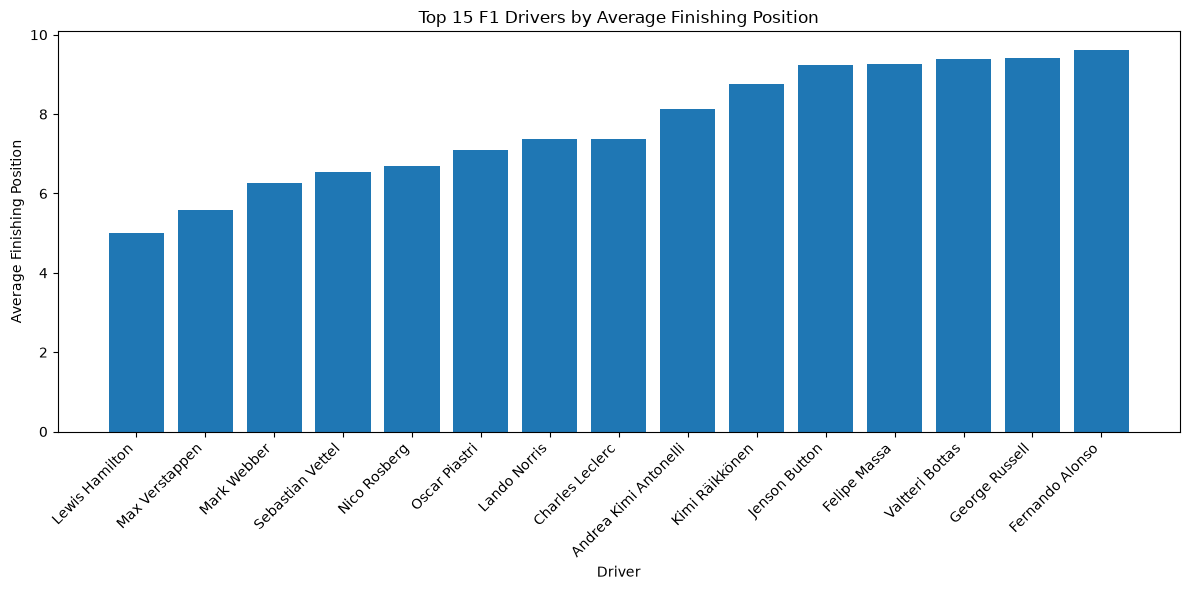

In [23]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_finish.index,
    driver_finish.values
)

plt.xlabel("Driver")
plt.ylabel("Average Finishing Position")
plt.title("Top 15 F1 Drivers by Average Finishing Position")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 22 — Analyze Constructor Average Finishing Position

In [24]:
constructor_finish = (
    df.groupby("constructor_name")["positionOrder"]
    .mean()
    .sort_values()
    .head(15)
)

constructor_finish

constructor_name
Mercedes           5.989660
Red Bull           6.389630
Ferrari            6.777286
McLaren            9.260741
Racing Point      10.631579
Force India       10.912181
Lotus F1          11.311688
Alpine F1 Team    11.939516
Aston Martin      12.000000
Renault           12.110294
RB F1 Team        12.318966
AlphaTauri        12.373494
Toro Rosso        13.160305
Audi              13.272727
Alfa Romeo        13.376812
Name: positionOrder, dtype: float64

### Step 23 — Plot Top 15 Constructors by Average Finishing Position

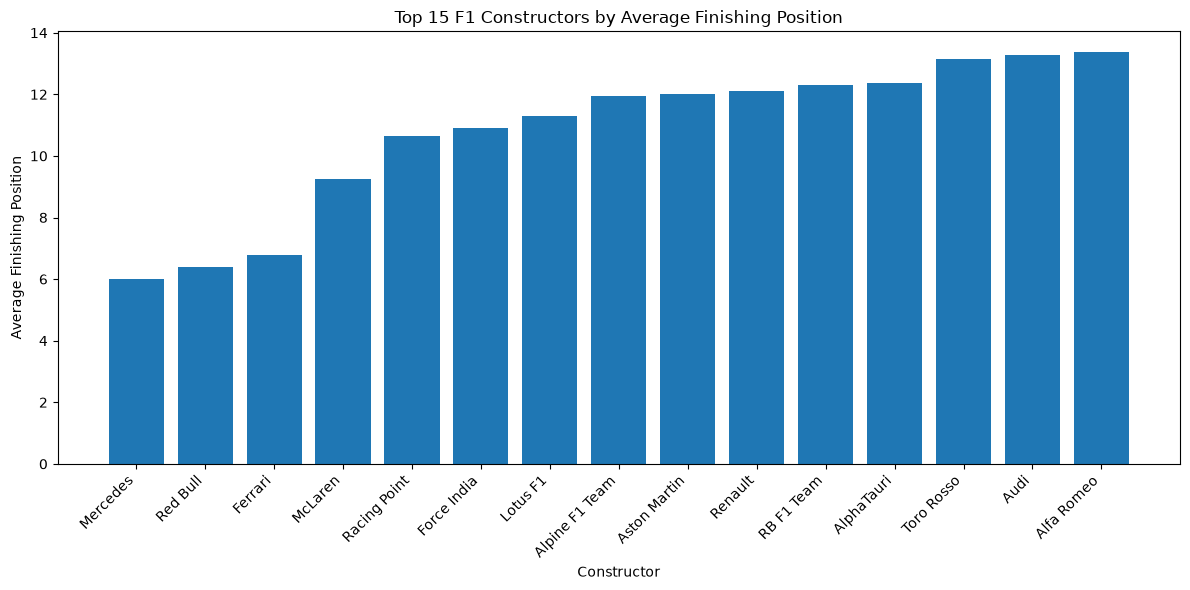

In [25]:
plt.figure(figsize=(12, 6))

plt.bar(
    constructor_finish.index,
    constructor_finish.values
)

plt.xlabel("Constructor")
plt.ylabel("Average Finishing Position")
plt.title("Top 15 F1 Constructors by Average Finishing Position")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 24 — Analyze Podium Performance by Circuit

In [26]:
circuit_podiums = (
    df.groupby("circuit_name")["podium"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

circuit_podiums

circuit_name
Silverstone Circuit               54
Circuit de Spa-Francorchamps      51
Circuit de Barcelona-Catalunya    51
Hungaroring                       51
Circuit de Monaco                 48
Yas Marina Circuit                48
Bahrain International Circuit     48
Autodromo Nazionale di Monza      48
Suzuka Circuit                    45
Albert Park Grand Prix Circuit    45
Red Bull Ring                     45
Circuit Gilles Villeneuve         45
Autódromo José Carlos Pace        45
Marina Bay Street Circuit         42
Circuit of the Americas           39
Name: podium, dtype: int64

### Step 25 — Plot Top 15 Circuits by Podium Count


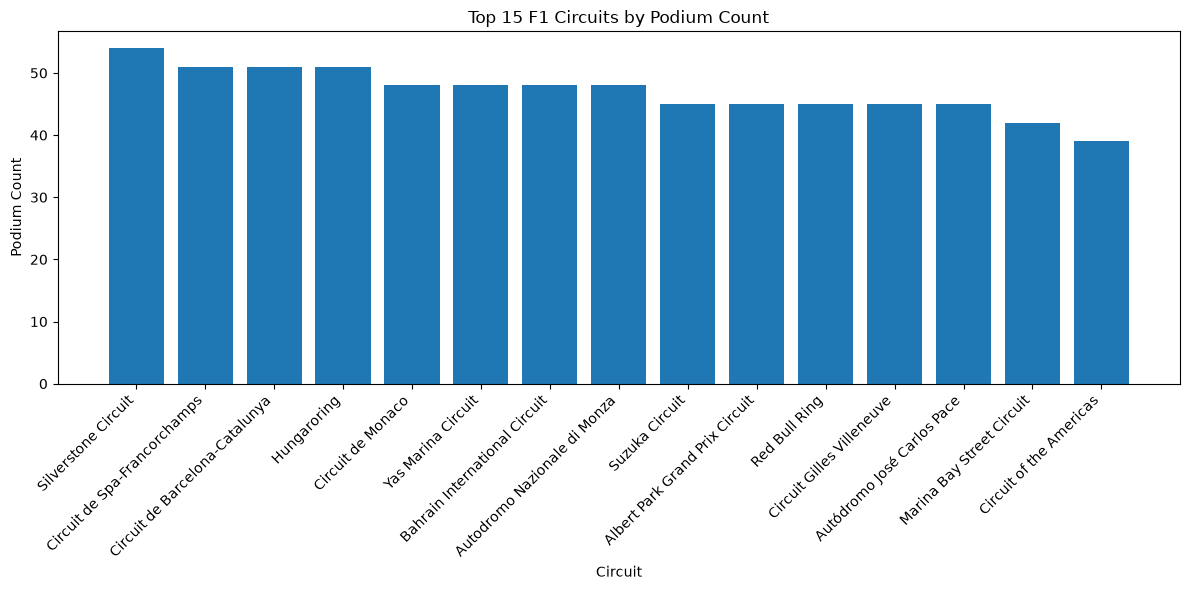

In [27]:
plt.figure(figsize=(12, 6))

plt.bar(
    circuit_podiums.index,
    circuit_podiums.values
)

plt.xlabel("Circuit")
plt.ylabel("Podium Count")
plt.title("Top 15 F1 Circuits by Podium Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 26 — Analyze Correlation Between Numerical Features

In [28]:
correlation_columns = [
    "grid",
    "qualifying_position",
    "positionOrder",
    "points",
    "laps",
    "fastestLap",
    "fastestLapSpeed",
    "podium"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,grid,qualifying_position,positionOrder,points,laps,fastestLap,fastestLapSpeed,podium
grid,1.000000,0.925655,0.597628,-0.629308,-0.096637,-0.089717,-0.115615,-0.487640
qualifying_position,0.925655,1.000000,0.639642,-0.663788,-0.109605,-0.091988,-0.119820,-0.507629
positionOrder,0.597628,0.639642,1.000000,-0.829873,-0.504916,-0.337131,-0.152984,-0.600350
points,-0.629308,-0.663788,-0.829873,1.000000,0.249760,0.184921,0.105143,0.835783
laps,-0.096637,-0.109605,-0.504916,0.249760,1.000000,0.578472,-0.069225,0.149750
fastestLap,-0.089717,-0.091988,-0.337131,0.184921,0.578472,1.000000,0.040980,0.113228
fastestLapSpeed,-0.115615,-0.119820,-0.152984,0.105143,-0.069225,0.040980,1.000000,0.075156
podium,-0.487640,-0.507629,-0.600350,0.835783,0.149750,0.113228,0.075156,1.000000


### Step 27 — Plot Correlation Matrix

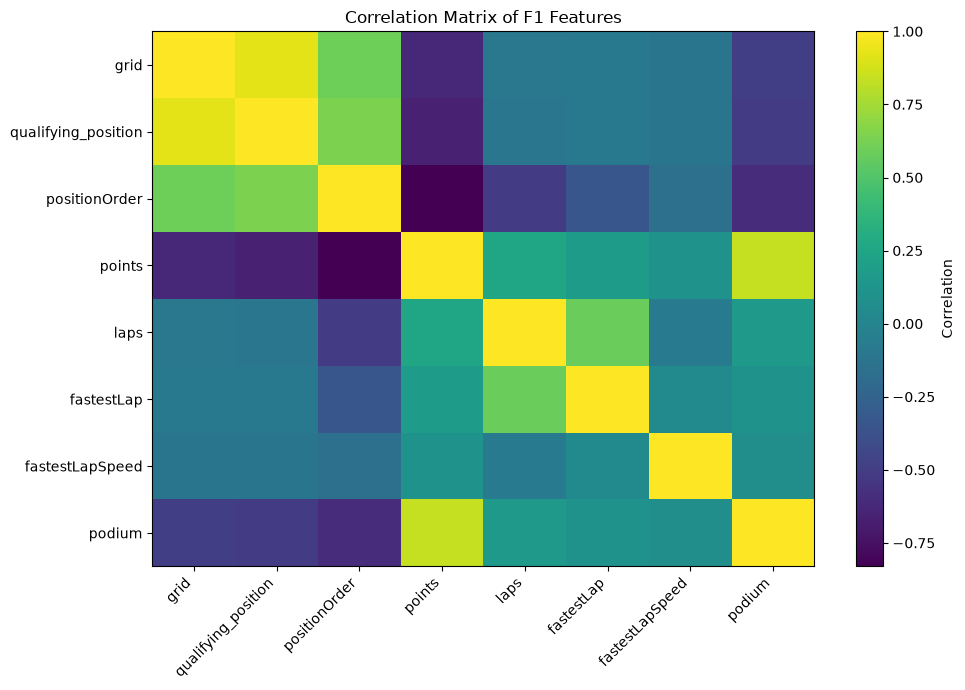

In [29]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix of F1 Features")
plt.tight_layout()

plt.show()

### Step 28 — Analyze Grid vs Qualifying Position

In [30]:
grid_qualifying = (
    df.groupby("qualifying_position")["grid"]
    .mean()
)

grid_qualifying.head(20)

qualifying_position
1.0      1.309735
2.0      2.327434
3.0      3.262537
4.0      4.200590
5.0      5.126844
6.0      6.008850
7.0      6.926254
8.0      7.952802
9.0      9.011799
10.0    10.053097
11.0    10.949853
12.0    11.935294
13.0    12.900000
14.0    13.615385
15.0    15.309735
16.0    15.545723
17.0    16.528024
18.0    17.271386
19.0    17.546547
20.0    18.458204
Name: grid, dtype: float64

#### Step 29 — Plot Grid vs Qualifying Position

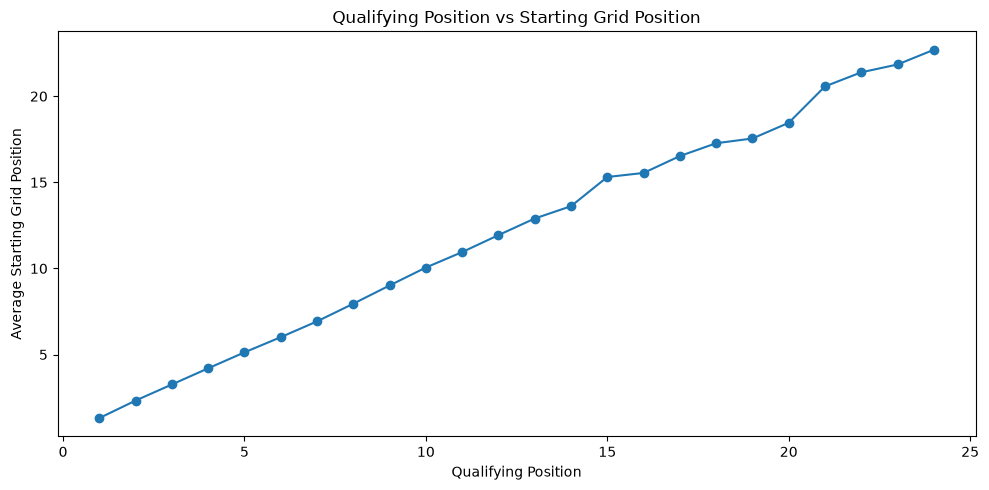

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    grid_qualifying.index,
    grid_qualifying.values,
    marker="o"
)

plt.xlabel("Qualifying Position")
plt.ylabel("Average Starting Grid Position")
plt.title("Qualifying Position vs Starting Grid Position")

plt.tight_layout()
plt.show()

### Step 30 — Analyze Fastest Lap Speed by Driver


In [32]:
driver_speed = (
    df.groupby("driver_name")["fastestLapSpeed"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

driver_speed

driver_name
Jack Aitken           222.240000
Nyck de Vries         213.478727
Logan Sargeant        210.413792
Lando Norris          210.237330
Charles Leclerc       209.904454
George Russell        209.401540
Antonio Giovinazzi    209.273951
Oscar Piastri         209.127612
Alexander Albon       208.960815
Guanyu Zhou           208.871103
Lance Stroll          208.780487
Pietro Fittipaldi     208.740000
Max Verstappen        208.653031
Pierre Gasly          208.532201
Yuki Tsunoda          207.906907
Name: fastestLapSpeed, dtype: float64

### Step 31 — Plot Top 15 Drivers by Average Fastest Lap Speed

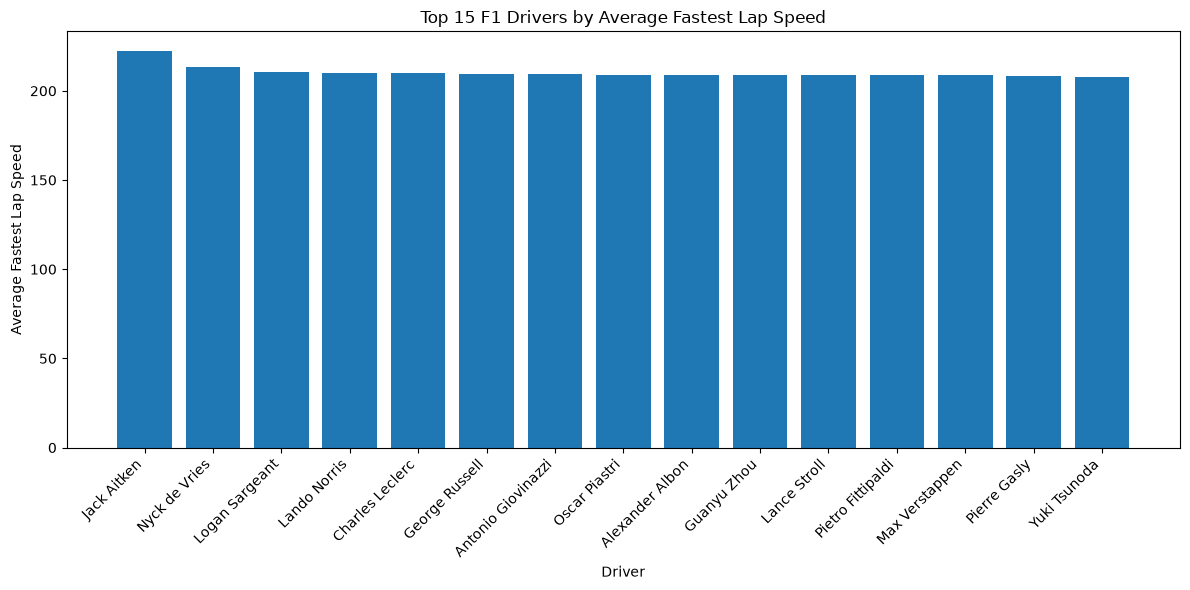

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_speed.index,
    driver_speed.values
)

plt.xlabel("Driver")
plt.ylabel("Average Fastest Lap Speed")
plt.title("Top 15 F1 Drivers by Average Fastest Lap Speed")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 32 — Analyze Average Points by Constructor

In [34]:
constructor_points = (
    df.groupby("constructor_name")["points"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

constructor_points

constructor_name
Mercedes          12.288774
Red Bull          11.745926
Ferrari            9.909292
McLaren            6.502222
Lotus F1           4.584416
Racing Point       3.723684
Force India        3.073654
Renault            2.540441
Alpine F1 Team     2.330645
Aston Martin       2.304878
AlphaTauri         1.843373
Williams           1.711111
RB F1 Team         1.620690
Toro Rosso         1.127226
Sauber             0.979730
Name: points, dtype: float64

### Step 33 — Plot Top 15 Constructors by Average Points

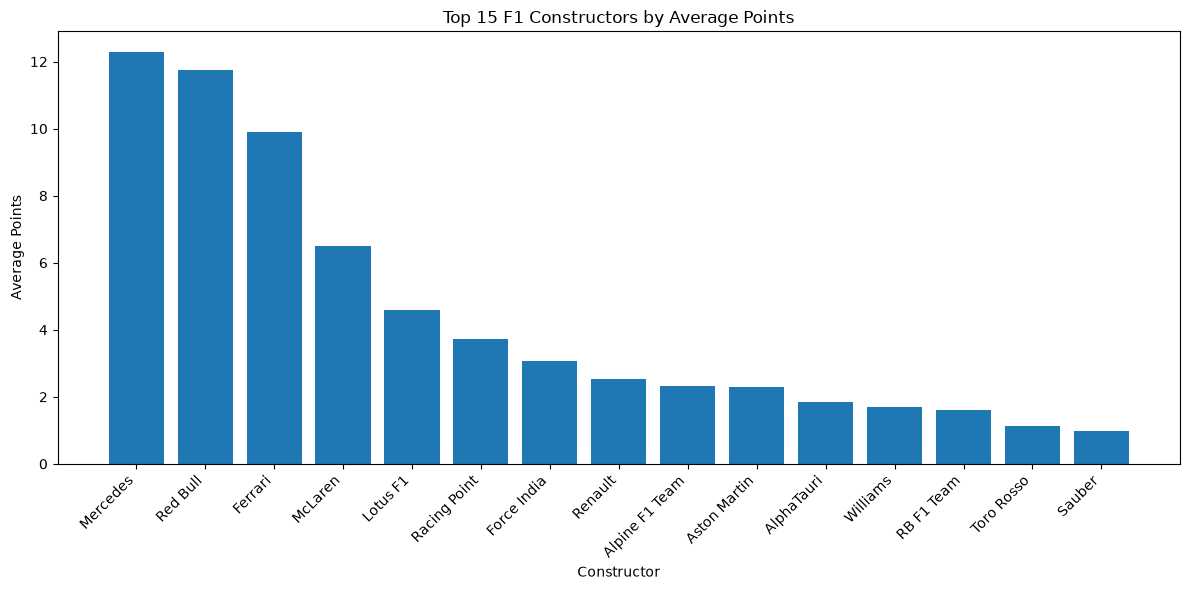

In [35]:
plt.figure(figsize=(12, 6))

plt.bar(
    constructor_points.index,
    constructor_points.values
)

plt.xlabel("Constructor")
plt.ylabel("Average Points")
plt.title("Top 15 F1 Constructors by Average Points")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 34 — Analyze Driver Performance by Season

In [36]:
driver_season = (
    df.groupby(["year", "driver_name"])["points"]
    .sum()
    .reset_index()
)

driver_season.head()

,year,driver_name,points
0,2010,Adrian Sutil,47.0
1,2010,Bruno Senna,0.0
2,2010,Christian Klien,0.0
3,2010,Felipe Massa,144.0
4,2010,Fernando Alonso,252.0


### Step 35 — Top Drivers by Season Point

In [37]:
top_drivers_season = (
    driver_season
    .sort_values(
        ["year", "points"],
        ascending=[False, False]
    )
)

top_drivers_season.head(20)

,year,driver_name,points
372,2026,Andrea Kimi Antonelli,198.0
384,2026,Lewis Hamilton,151.0
380,2026,George Russell,134.0
375,2026,Charles Leclerc,117.0
383,2026,Lando Norris,102.0
386,2026,Max Verstappen,92.0
389,2026,Oscar Piastri,75.0
381,2026,Isack Hadjar,68.0
390,2026,Pierre Gasly,41.0
385,2026,Liam Lawson,40.0


### Step 36 — Analyze Constructor Performance by Season

In [39]:
constructor_season = (
    df.groupby(["year", "constructor_name"])["points"]
    .sum()
    .reset_index()
)

constructor_season.head()

,year,constructor_name,points
0,2010,Ferrari,396.0
1,2010,Force India,68.0
2,2010,HRT,0.0
3,2010,Lotus,0.0
4,2010,McLaren,454.0


### Step 37 — Top Constructors by Season Points

In [40]:
top_constructors_season = (
    constructor_season
    .sort_values(
        ["year", "points"],
        ascending=[False, False]
    )
)

top_constructors_season.head(20)

,year,constructor_name,points
176,2026,Mercedes,332.0
173,2026,Ferrari,268.0
175,2026,McLaren,177.0
178,2026,Red Bull,160.0
177,2026,RB F1 Team,62.0
169,2026,Alpine F1 Team,60.0
174,2026,Haas F1 Team,20.0
171,2026,Audi,12.0
179,2026,Williams,11.0
170,2026,Aston Martin,1.0


### Step 38 — Analyze Driver Win Count

In [41]:
driver_wins = (
    df[df["positionOrder"] == 1]
    .groupby("driver_name")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

driver_wins

driver_name
Lewis Hamilton           95
Max Verstappen           70
Sebastian Vettel         48
Nico Rosberg             23
Lando Norris             12
Fernando Alonso          11
Valtteri Bottas          10
Charles Leclerc           9
Oscar Piastri             9
Jenson Button             8
Daniel Ricciardo          8
Mark Webber               7
George Russell            7
Andrea Kimi Antonelli     6
Sergio Pérez              6
dtype: int64

#### Step 39 — Plot Top 15 Drivers by Race Wins

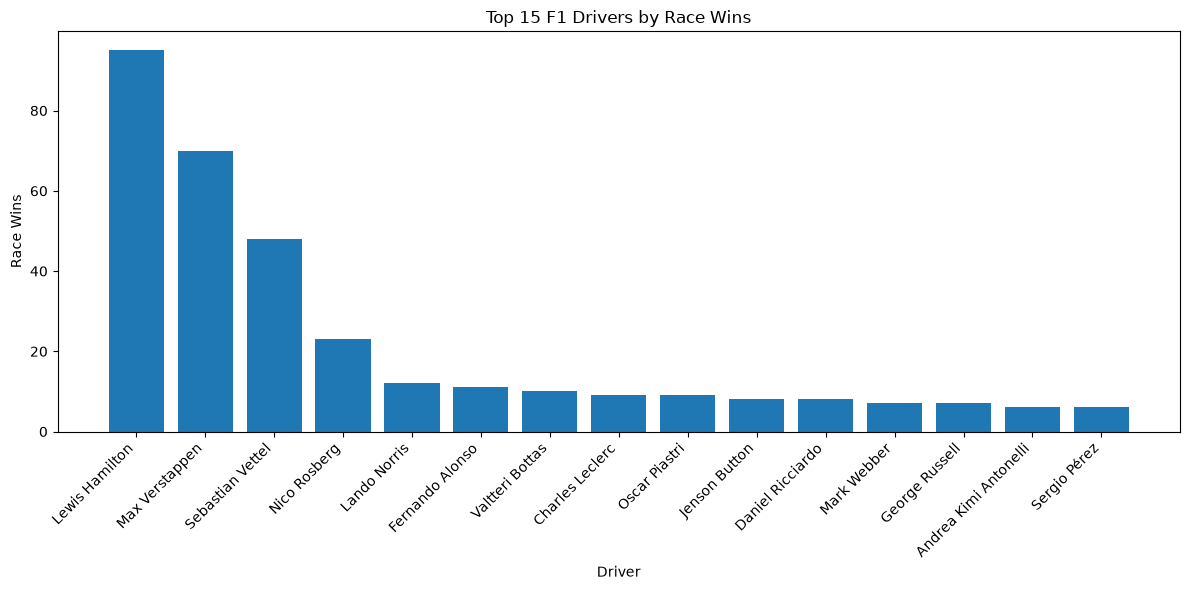

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_wins.index,
    driver_wins.values
)

plt.xlabel("Driver")
plt.ylabel("Race Wins")
plt.title("Top 15 F1 Drivers by Race Wins")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 40 — Analyze Constructor Win Count

In [43]:
constructor_wins = (
    df[df["positionOrder"] == 1]
    .groupby("constructor_name")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

constructor_wins

constructor_name
Mercedes          130
Red Bull          123
Ferrari            40
McLaren            40
Lotus F1            2
AlphaTauri          1
Alpine F1 Team      1
Racing Point        1
Williams            1
dtype: int64

### Step 41 — Plot Top 15 Constructors by Race Wins

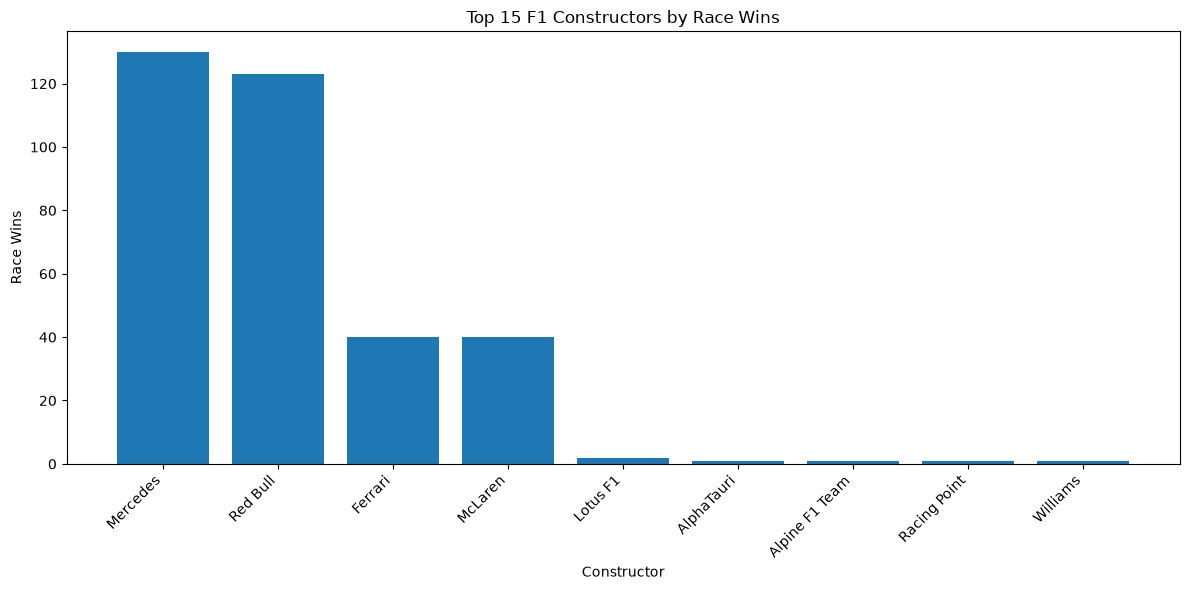

In [44]:
plt.figure(figsize=(12, 6))

plt.bar(
    constructor_wins.index,
    constructor_wins.values
)

plt.xlabel("Constructor")
plt.ylabel("Race Wins")
plt.title("Top 15 F1 Constructors by Race Wins")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 42 — Analyze Podium Rate by Driver

In [45]:
driver_podium_rate = (
    df.groupby("driver_name")["podium"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

driver_podium_rate

driver_name
Max Verstappen           53.719008
Lewis Hamilton           53.254438
Sebastian Vettel         44.140625
Mark Webber              41.558442
Nico Rosberg             40.441176
Andrea Kimi Antonelli    35.294118
Oscar Piastri            33.750000
Charles Leclerc          29.508197
Lando Norris             29.012346
Valtteri Bottas          25.968992
Kimi Räikkönen           21.025641
Jenson Button            19.259259
George Russell           17.901235
Fernando Alonso          17.845118
Sergio Pérez             13.310580
Name: podium, dtype: float64

### Step 43 — Plot Top 15 Drivers by Podium Rate

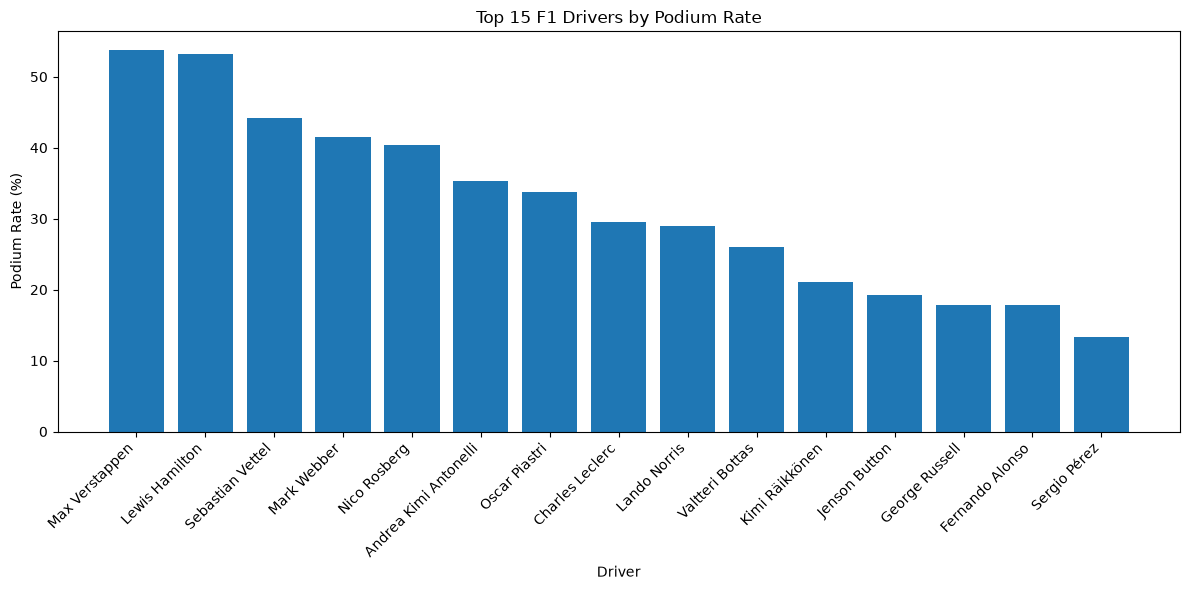

In [46]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_podium_rate.index,
    driver_podium_rate.values
)

plt.xlabel("Driver")
plt.ylabel("Podium Rate (%)")
plt.title("Top 15 F1 Drivers by Podium Rate")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## #  Step 44 — Analyze Podium Rate by Constructor

In [47]:
constructor_podium_rate = (
    df.groupby("constructor_name")["podium"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

constructor_podium_rate

constructor_name
Mercedes          45.347120
Red Bull          41.629630
Ferrari           32.005900
McLaren           18.666667
Lotus F1          16.233766
Racing Point       5.263158
Aston Martin       3.658537
Renault            2.941176
Alpine F1 Team     2.822581
Williams           2.666667
Force India        1.416431
AlphaTauri         1.204819
Sauber             1.126126
RB F1 Team         0.862069
Toro Rosso         0.508906
Name: podium, dtype: float64

### Step 45 — Plot Top 15 Constructors by Podium Rate

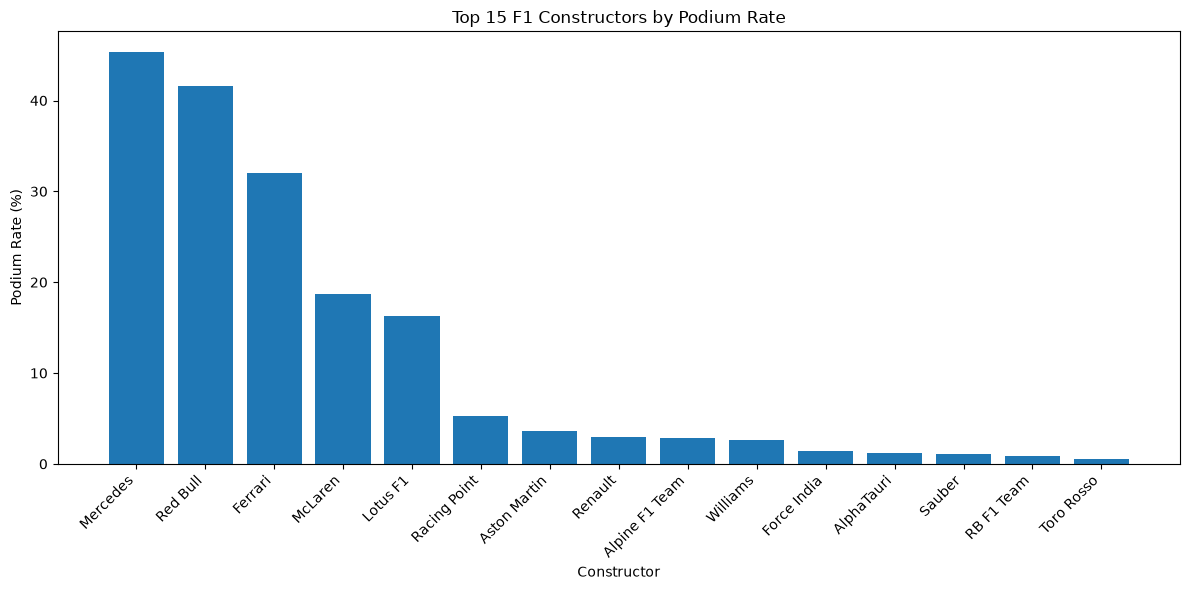

In [48]:
plt.figure(figsize=(12, 6))

plt.bar(
    constructor_podium_rate.index,
    constructor_podium_rate.values
)

plt.xlabel("Constructor")
plt.ylabel("Podium Rate (%)")
plt.title("Top 15 F1 Constructors by Podium Rate")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 46 — Analyze Circuit Performance by Average Finishing Position

In [49]:
circuit_finish = (
    df.groupby("circuit_name")["positionOrder"]
    .mean()
    .sort_values()
    .head(15)
)

circuit_finish

circuit_name
Autodromo Enzo e Dino Ferrari           10.500000
Autodromo Internazionale del Mugello    10.500000
Autódromo Internacional do Algarve      10.500000
Circuit Park Zandvoort                  10.500000
Circuit Paul Ricard                     10.500000
Jeddah Corniche Circuit                 10.500000
Losail International Circuit            10.500000
Las Vegas Strip Street Circuit          10.500000
Baku City Circuit                       10.569061
Autódromo Hermanos Rodríguez            10.580000
Sochi Autodrom                          10.666667
Miami International Autodrome           10.715686
Red Bull Ring                           10.715686
Circuit of the Americas                 10.778195
Bahrain International Circuit           10.957958
Name: positionOrder, dtype: float64

### Step 47 — Plot Top 15 Circuits by Average Finishing Position

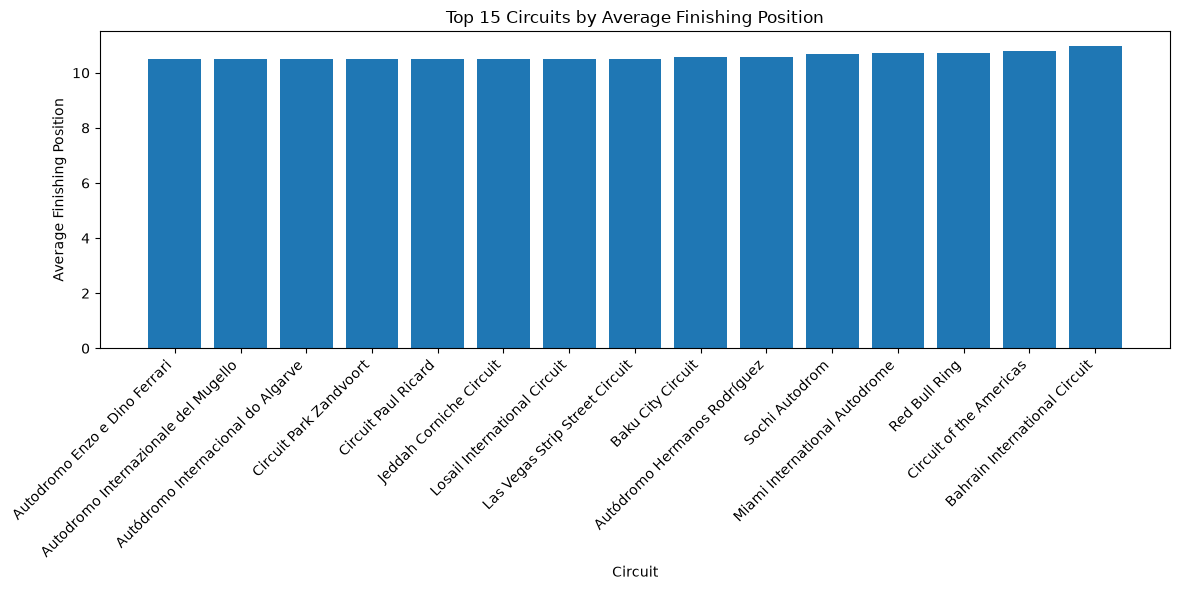

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(
    circuit_finish.index,
    circuit_finish.values
)

plt.xlabel("Circuit")
plt.ylabel("Average Finishing Position")
plt.title("Top 15 Circuits by Average Finishing Position")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Step 48 — Analyze Season-wise Average Points

In [51]:
season_points = (
    df.groupby("year")["points"]
    .sum()
)

season_points.tail(15)

year
2012    2020.0
2013    1919.0
2014    1988.0
2015    1919.0
2016    2115.0
2017    2020.0
2018    2121.0
2019    2139.0
2020    1734.0
2021    2189.5
2022    2242.0
2023    2242.0
2024    2443.0
2025    2323.0
2026    1103.0
Name: points, dtype: float64

### Step 49 — Plot Season-wise Total Points

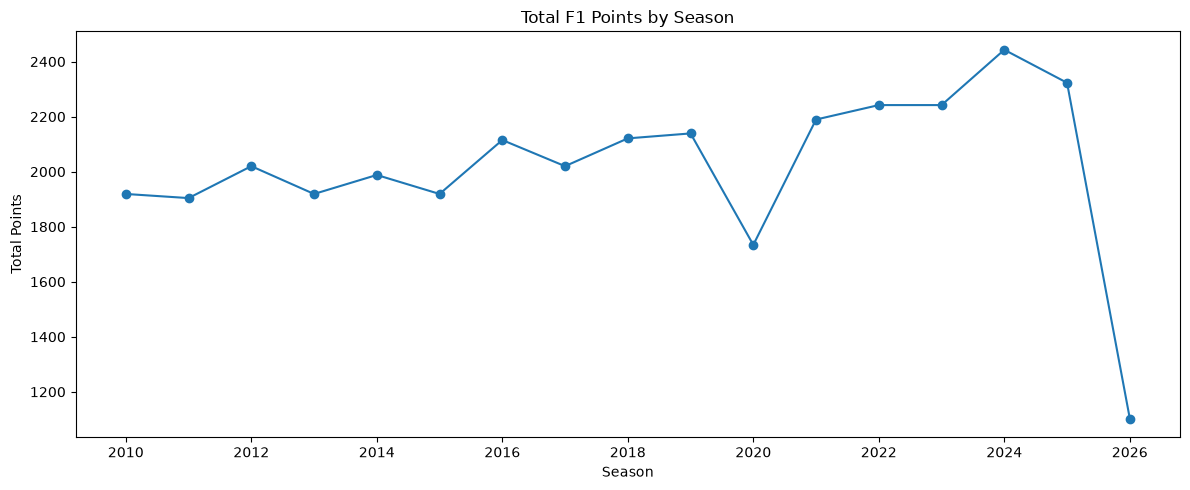

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    season_points.index,
    season_points.values,
    marker="o"
)

plt.xlabel("Season")
plt.ylabel("Total Points")
plt.title("Total F1 Points by Season")

plt.tight_layout()

plt.show()

### Step 50 — Analyze Driver Championship Performance

In [54]:
driver_championship = (
    df.groupby(["year", "driver_name"])["points"]
    .sum()
    .reset_index()
)

driver_championship = (
    driver_championship
    .sort_values(
        ["year", "points"],
        ascending=[False, False]
    )
)

driver_championship.head(20)

,year,driver_name,points
372,2026,Andrea Kimi Antonelli,198.0
384,2026,Lewis Hamilton,151.0
380,2026,George Russell,134.0
375,2026,Charles Leclerc,117.0
383,2026,Lando Norris,102.0
386,2026,Max Verstappen,92.0
389,2026,Oscar Piastri,75.0
381,2026,Isack Hadjar,68.0
390,2026,Pierre Gasly,41.0
385,2026,Liam Lawson,40.0


### Step 51 — Save EDA Summary Dataset

In [55]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Races",
        "Total Drivers",
        "Total Constructors",
        "Total Circuits",
        "Total Seasons"
    ],
    "Value": [
        df["raceId"].nunique(),
        df["driverId"].nunique(),
        df["constructorId"].nunique(),
        df["circuitId"].nunique(),
        df["year"].nunique()
    ]
})

eda_summary

,Metric,Value
0,Total Races,339
1,Total Drivers,84
2,Total Constructors,25
3,Total Circuits,35
4,Total Seasons,17


### Step 52 — Save EDA Summary

In [56]:
eda_summary.to_csv(
    "../Dataset/f1_eda_summary.csv",
    index=False
)

print("EDA summary saved successfully!")

EDA summary saved successfully!
